house hold data set FRAUD DETECTION USING KNN (K NEAREST NEIGHBOUR)

In [ ]:
import pandas as  pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score

In [ ]:
df = pd.read_csv("/content/House Price Prediction Dataset.csv")
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [ ]:
df.shape

(2000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
df['Price'].value_counts()

,count
Price,
959222,2
386433,1
77597,1
530545,1
419170,1
...,...
55310,1
100272,1
523267,1


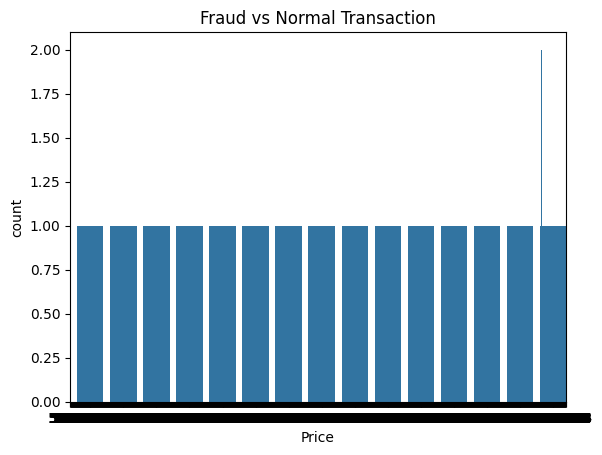

In [ ]:
sns.countplot(x ='Price',data = df)
plt .title("Fraud vs Normal Transaction")
plt.show()

In [ ]:
#FEATURE SCALING AND Target Selection
X = df.drop('Price',axis =1)
y = df['Price']

In [ ]:
#DATA SCALe
# Identify categorical columns
categorical_cols = ['Location', 'Condition', 'Garage']

# Apply one-hot encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [ ]:
#SPLIT DATA SET
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [52]:
#TRAIN KNN MODEL k nearest neigbhors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [53]:
#PREDICTIONS
y_pred = knn.predict(X_test)

In [54]:
#Model Evolution
cm = confusion_matrix(y_test,y_pred)
cm

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [56]:
print("\nAccuracy:",accuracy_score(y_test,y_pred))


Accuracy: 0.0


In [60]:
print("\nClassification Report:")
print(classification_report(y_test,y_pred))


Classification Report:
              precision    recall  f1-score   support

       50005       0.00      0.00      0.00       0.0
       50064       0.00      0.00      0.00       0.0
       51082       0.00      0.00      0.00       1.0
       51845       0.00      0.00      0.00       1.0
       52631       0.00      0.00      0.00       1.0
       53052       0.00      0.00      0.00       0.0
       53657       0.00      0.00      0.00       1.0
       53743       0.00      0.00      0.00       0.0
       53889       0.00      0.00      0.00       0.0
       54090       0.00      0.00      0.00       1.0
       54329       0.00      0.00      0.00       0.0
       55310       0.00      0.00      0.00       0.0
       56457       0.00      0.00      0.00       0.0
       56611       0.00      0.00      0.00       1.0
       57176       0.00      0.00      0.00       0.0
       58539       0.00      0.00      0.00       0.0
       58981       0.00      0.00      0.00       0.0
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

<function matplotlib.pyplot.show(close=None, block=None)>

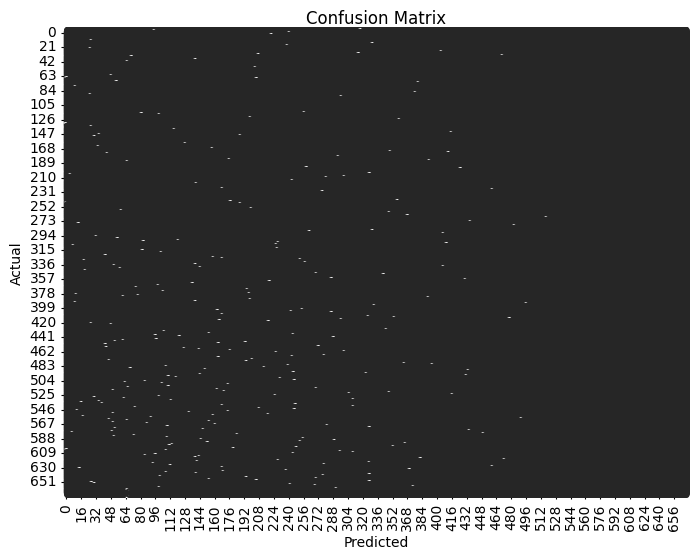

In [61]:
#CONFUSION MATRIX
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show

In [ ]:
#PREDICT SINGLE TRANSACTION
Prediction = knn.predict(X_test)

In [62]:
sample =X_test[0].reshape(1,-1)
prediction = knn .predict(sample)
if prediction[0].reshape(1,-1) == 0:
  print("Normal Transaction")
else:
  print("Fraudulent Transaction")

Fraudulent Transaction
